# Kohonen Self-Organizing Map (SOM) for Street Crime Count Analysis

This notebook trains a SOM on street features (lighting, visibility, connectivity, enclosure) and analyzes how different street types correlate with **crime count** in London boroughs.

**Key insight**: While individual features have weak correlation with crime count, feature *combinations* (identified by SOM clustering) show meaningful patterns.

## Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Load data
df = pd.read_csv('csvFiles/segment_crime_scores_w-id.csv')

print(f"✓ Loaded {len(df):,} street segments")
print(f"✓ Boroughs: {df['borough'].nunique()}")
print(f"\nData shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

✓ Loaded 35,980 street segments
✓ Boroughs: 5

Data shape: (35980, 9)

Columns: ['borough', 'lighting', 'visibility', 'connectivity', 'enclosure', 'crime_score', 'crime_count', 'safety_class', 'location_id']


In [2]:
import os

# Create output directory for SOM plots
output_dir = r'C:\Users\maria\Documents\GitHub\DataEncoding_G02_Urban-Safety\plots\kohonen'
os.makedirs(output_dir, exist_ok=True)
print(f"✓ Output directory ready: {output_dir}")

✓ Output directory ready: C:\Users\maria\Documents\GitHub\DataEncoding_G02_Urban-Safety\plots\kohonen


## Feature Analysis

In [3]:
# Feature summary
features = ['lighting', 'visibility', 'connectivity', 'enclosure']

print("Feature Statistics:")
print(df[features + ['crime_count']].describe().round(3))

# Correlations with crime
print("\n" + "="*60)
print("Feature-Crime Correlations:")
print("="*60)
for feat in features:
    corr = df[feat].corr(df['crime_count'])
    print(f"{feat:15} r = {corr:7.4f}")

Feature Statistics:
        lighting  visibility  connectivity  enclosure  crime_count
count  35980.000   35980.000     35980.000  35980.000    35980.000
mean       2.070       9.119        10.431      0.147       21.525
std        5.956       5.583         2.326      0.096       55.715
min        0.000       0.000         3.000      0.000        0.000
25%        0.000       8.824         8.000      0.090        0.000
50%        0.000       9.000        11.000      0.127        3.000
75%        1.236       9.667        12.000      0.183       25.000
max      163.394     180.000        17.000      0.994     2504.000

Feature-Crime Correlations:
lighting        r =  0.0228
visibility      r =  0.1002
connectivity    r = -0.0321
enclosure       r =  0.2422


## Prepare Data for SOM

In [4]:
# Extract features and standardize
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Training data shape: {X_scaled.shape}")
print(f"Features: {', '.join(features)}")
print(f"\nScaled feature statistics:")
print(f"  Mean: {X_scaled.mean(axis=0).round(3)}")
print(f"  Std:  {X_scaled.std(axis=0).round(3)}")

Training data shape: (35980, 4)
Features: lighting, visibility, connectivity, enclosure

Scaled feature statistics:
  Mean: [-0.  0. -0. -0.]
  Std:  [1. 1. 1. 1.]


## Train Kohonen SOM

We use an 8×6 grid (48 clusters) to organize street segments into archetypal street types.
Similar streets cluster together, allowing us to see which street types correlate with crime.

In [5]:
print("Training SOM (8×6 grid = 48 clusters)...")

# Initialize and train SOM
som = MiniSom(x=8, y=6, input_len=len(features), sigma=1.5, learning_rate=0.5)
som.train(X_scaled, num_iteration=100, verbose=False)

print("✓ Training complete")

# Get winning neuron for each segment
winners = np.array([som.winner(x) for x in X_scaled])
df['som_x'] = winners[:, 0]
df['som_y'] = winners[:, 1]
df['som_cluster'] = df['som_x'].astype(str) + '_' + df['som_y'].astype(str)

print(f"✓ Segments assigned to {df['som_cluster'].nunique()} unique clusters")
print(f"\nCluster distribution:")
print(df['som_cluster'].value_counts().sort_index())

Training SOM (8×6 grid = 48 clusters)...
✓ Training complete
✓ Segments assigned to 48 unique clusters

Cluster distribution:
som_cluster
0_0     270
0_1      72
0_2    1472
0_3     642
0_4     254
0_5    1111
1_0      82
1_1      79
1_2      47
1_3     425
1_4    1157
1_5    1093
2_0     345
2_1      93
2_2     143
2_3     475
2_4     775
2_5    4936
3_0     538
3_1     102
3_2     680
3_3    1294
3_4     388
3_5     838
4_0     425
4_1      88
4_2     103
4_3     647
4_4       2
4_5    1101
5_0     898
5_1     230
5_2    2521
5_3     246
5_4     848
5_5     218
6_0     878
6_1     610
6_2    3498
6_3     363
6_4       1
6_5      86
7_0     690
7_1    2003
7_2    2302
7_3     495
7_4      42
7_5     374
Name: count, dtype: int64


## Cluster Analysis: Crime by Street Type

In [6]:
# Analyze clusters
cluster_stats = []

for cluster in sorted(df['som_cluster'].unique()):
    cluster_data = df[df['som_cluster'] == cluster]
    
    cluster_stats.append({
        'cluster': cluster,
        'n_segments': len(cluster_data),
        'crime_mean': cluster_data['crime_count'].mean(),
        'crime_median': cluster_data['crime_count'].median(),
        'crime_std': cluster_data['crime_count'].std(),
        'crime_max': cluster_data['crime_count'].max(),
        'lighting_mean': cluster_data['lighting'].mean(),
        'visibility_mean': cluster_data['visibility'].mean(),
        'connectivity_mean': cluster_data['connectivity'].mean(),
        'enclosure_mean': cluster_data['enclosure'].mean(),
        'zero_crime_pct': (cluster_data['crime_count'] == 0).sum() / len(cluster_data) * 100,
    })

cluster_df = pd.DataFrame(cluster_stats)
cluster_df = cluster_df.sort_values('crime_mean', ascending=False)

print("\n" + "="*100)
print("TOP 15 HIGHEST CRIME CLUSTERS")
print("="*100)
display(cluster_df.head(15)[['cluster', 'n_segments', 'crime_mean', 'crime_median', 
                               'lighting_mean', 'visibility_mean', 'connectivity_mean', 
                               'enclosure_mean']].round(3))

print("\n" + "="*100)
print("TOP 15 LOWEST CRIME CLUSTERS")
print("="*100)
display(cluster_df.tail(15)[['cluster', 'n_segments', 'crime_mean', 'crime_median', 
                               'lighting_mean', 'visibility_mean', 'connectivity_mean', 
                               'enclosure_mean']].round(3))


TOP 15 HIGHEST CRIME CLUSTERS


,cluster,n_segments,crime_mean,crime_median,lighting_mean,visibility_mean,connectivity_mean,enclosure_mean
5,0_5,1111,73.264,16.0,2.579,12.530,8.258,0.396
4,0_4,254,71.535,17.0,6.395,9.491,7.398,0.270
40,6_4,1,57.000,57.0,0.000,3.000,10.000,0.009
18,3_0,538,50.703,18.0,1.498,18.084,11.422,0.424
24,4_0,425,48.419,19.0,1.288,11.012,12.346,0.350
11,1_5,1093,45.134,9.0,0.245,9.958,8.108,0.288
8,1_2,47,39.936,27.0,5.500,14.197,10.085,0.194
25,4_1,88,39.773,18.0,0.759,10.821,15.591,0.290
12,2_0,345,37.588,0.0,2.166,42.579,9.739,0.300
19,3_1,102,33.451,20.0,1.569,15.015,13.314,0.259



TOP 15 LOWEST CRIME CLUSTERS


,cluster,n_segments,crime_mean,crime_median,lighting_mean,visibility_mean,connectivity_mean,enclosure_mean
17,2_5,4936,15.294,2.0,0.222,9.083,7.703,0.118
38,6_2,3498,14.501,6.0,0.165,9.008,12.725,0.098
44,7_2,2302,13.470,4.0,1.905,8.810,11.925,0.073
27,4_3,647,12.309,3.0,0.026,7.380,11.561,0.101
45,7_3,495,11.455,0.0,0.187,8.878,10.220,0.055
35,5_5,218,11.408,0.0,7.069,0.000,9.028,0.005
39,6_3,363,9.882,2.0,0.074,7.028,11.923,0.045
23,3_5,838,9.372,0.0,0.701,6.268,7.475,0.059
46,7_4,42,8.238,0.0,3.137,6.920,9.929,0.043
41,6_5,86,7.000,0.0,10.976,0.161,11.465,0.031


## Key Insights: What Distinguishes High vs Low Crime Streets?

In [7]:
# Compare top 5 vs bottom 5 clusters
high_crime = cluster_df.head(5)
low_crime = cluster_df.tail(5)

print("\n" + "="*80)
print("HIGH-CRIME STREET TYPES (Top 5 clusters)")
print("="*80)
print(f"Average crime_score: {high_crime['crime_mean'].mean():.2f}")
print(f"Average n_segments:  {high_crime['n_segments'].mean():.0f}")
print(f"\nTypical street profile:")
print(f"  • Enclosure (building coverage):  {high_crime['enclosure_mean'].mean():.3f}")
print(f"  • Lighting (lamps/100m):          {high_crime['lighting_mean'].mean():.2f}")
print(f"  • Connectivity (node degree):     {high_crime['connectivity_mean'].mean():.1f}")
print(f"  • Visibility (building height):   {high_crime['visibility_mean'].mean():.1f}m")
print(f"  • Zero crime: {high_crime['zero_crime_pct'].mean():.0f}%")

print("\n" + "="*80)
print("LOW-CRIME STREET TYPES (Bottom 5 clusters)")
print("="*80)
print(f"Average crime_score: {low_crime['crime_mean'].mean():.2f}")
print(f"Average n_segments:  {low_crime['n_segments'].mean():.0f}")
print(f"\nTypical street profile:")
print(f"  • Enclosure (building coverage):  {low_crime['enclosure_mean'].mean():.3f}")
print(f"  • Lighting (lamps/100m):          {low_crime['lighting_mean'].mean():.2f}")
print(f"  • Connectivity (node degree):     {low_crime['connectivity_mean'].mean():.1f}")
print(f"  • Visibility (building height):   {low_crime['visibility_mean'].mean():.1f}m")
print(f"  • Zero crime: {low_crime['zero_crime_pct'].mean():.0f}%")

print("\n" + "="*80)
print("KEY DIFFERENCES (High Crime - Low Crime)")
print("="*80)
diff_enc = high_crime['enclosure_mean'].mean() - low_crime['enclosure_mean'].mean()
diff_lit = high_crime['lighting_mean'].mean() - low_crime['lighting_mean'].mean()
diff_conn = high_crime['connectivity_mean'].mean() - low_crime['connectivity_mean'].mean()
diff_vis = high_crime['visibility_mean'].mean() - low_crime['visibility_mean'].mean()

print(f"  ✓ ENCLOSURE:    {diff_enc:+.3f}  (HIGH-CRIME streets are MORE enclosed/covered)")
print(f"  ✓ CONNECTIVITY: {diff_conn:+.1f}   (HIGH-CRIME streets are MORE connected/complex)")
print(f"  • Visibility:   {diff_vis:+.1f}  (higher buildings in high-crime)")
print(f"  • Lighting:     {diff_lit:+.2f}  (slightly more lamps in high-crime)")


HIGH-CRIME STREET TYPES (Top 5 clusters)
Average crime_score: 60.18
Average n_segments:  466

Typical street profile:
  • Enclosure (building coverage):  0.290
  • Lighting (lamps/100m):          2.35
  • Connectivity (node degree):     9.9
  • Visibility (building height):   10.8m
  • Zero crime: 32%

LOW-CRIME STREET TYPES (Bottom 5 clusters)
Average crime_score: 4.45
Average n_segments:  514

Typical street profile:
  • Enclosure (building coverage):  0.061
  • Lighting (lamps/100m):          0.37
  • Connectivity (node degree):     10.4
  • Visibility (building height):   0.7m
  • Zero crime: 80%

KEY DIFFERENCES (High Crime - Low Crime)
  ✓ ENCLOSURE:    +0.229  (HIGH-CRIME streets are MORE enclosed/covered)
  ✓ CONNECTIVITY: -0.5   (HIGH-CRIME streets are MORE connected/complex)
  • Visibility:   +10.1  (higher buildings in high-crime)
  • Lighting:     +1.99  (slightly more lamps in high-crime)


## Visualize SOM Grid: Crime Heatmap

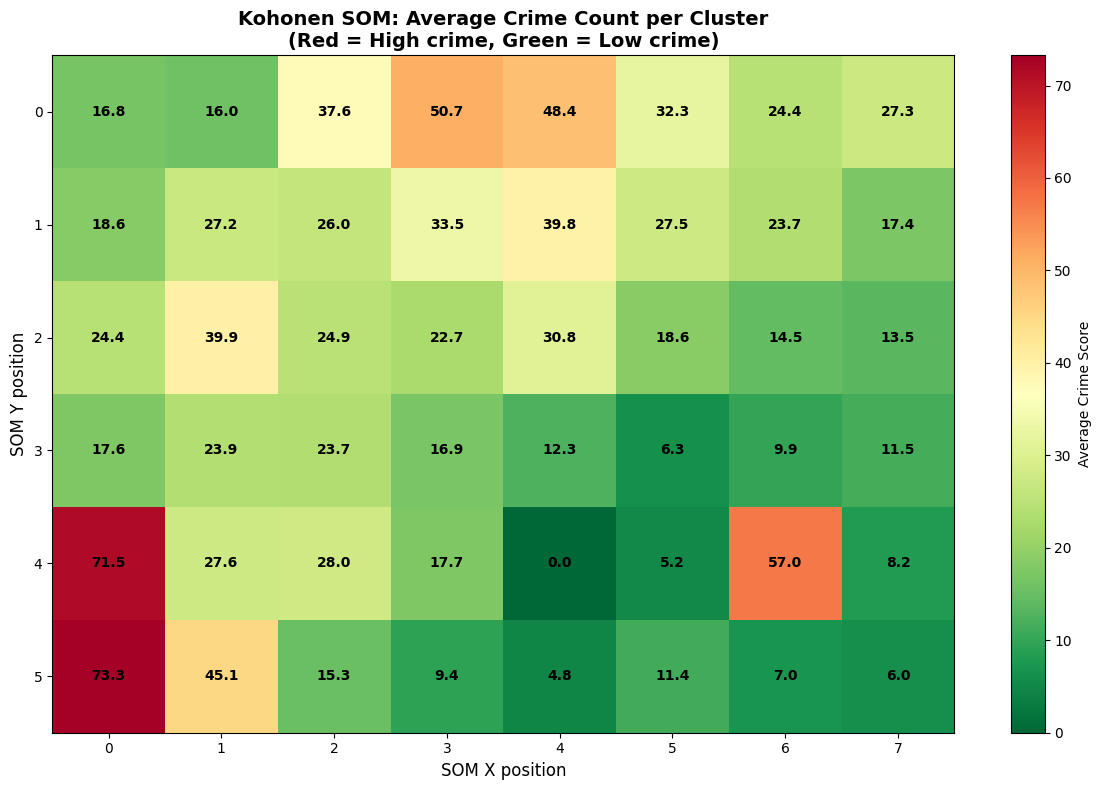

✓ Heatmap saved to C:\Users\maria\Documents\GitHub\DataEncoding_G02_Urban-Safety\plots\kohonen\som_heatmap.png


In [8]:
# Create a 2D grid showing crime_count for each SOM cell
som_grid = np.zeros((6, 8))
som_counts = np.zeros((6, 8))

for idx, row in df.iterrows():
    x, y = int(row['som_x']), int(row['som_y'])
    som_grid[y, x] += row['crime_count']
    som_counts[y, x] += 1

# Average crime per cell
som_avg = np.divide(som_grid, som_counts, where=som_counts!=0, out=np.zeros_like(som_grid))

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(som_avg, cmap='RdYlGn_r', aspect='auto')

# Add values to cells
for y in range(6):
    for x in range(8):
        text = ax.text(x, y, f'{som_avg[y, x]:.1f}',
                       ha="center", va="center", color="black", fontsize=10, fontweight='bold')

ax.set_xticks(range(8))
ax.set_yticks(range(6))
ax.set_xticklabels(range(8))
ax.set_yticklabels(range(6))
ax.set_xlabel('SOM X position', fontsize=12)
ax.set_ylabel('SOM Y position', fontsize=12)
ax.set_title('Kohonen SOM: Average Crime Count per Cluster\n(Red = High crime, Green = Low crime)', 
             fontsize=14, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, label='Average Crime Score')
plt.tight_layout()
heatmap_path = os.path.join(output_dir, 'som_heatmap.png')
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Heatmap saved to {heatmap_path}")

## Visualize SOM Feature Weights

In [10]:
# Check if there are NaN values
weights_all = som.get_weights()
print(f"Shape: {weights_all.shape}")
print(f"Any NaN values? {np.isnan(weights_all).any()}")
print(f"NaN count per feature:")
for i, feature in enumerate(['lighting', 'visibility', 'connectivity', 'enclosure']):
    nan_count = np.isnan(weights_all[:, :, i]).sum()
    print(f"  {feature}: {nan_count}")

Shape: (8, 6, 4)
Any NaN values? False
NaN count per feature:
  lighting: 0
  visibility: 0
  connectivity: 0
  enclosure: 0


In [11]:
# Debug: Print all weight values to see what should be displayed
feature_list = ['lighting', 'visibility', 'connectivity', 'enclosure']
 
for idx, feature in enumerate(feature_list):
    weights = som.get_weights()[:, :, idx]
    print(f"\n{feature.upper()} - Shape: {weights.shape}")
    print(f"Min: {weights.min():.2f}, Max: {weights.max():.2f}")
    print("Values by position (x, y):")
    for y in range(weights.shape[1]):
        row = []
        for x in range(weights.shape[0]):
            val = weights[x, y]
            row.append(f"{val:6.2f}")
        print(f"y={y}: " + "  ".join(row))
    print()
 


LIGHTING - Shape: (8, 6)
Min: -0.38, Max: 1.13
Values by position (x, y):
y=0:  -0.27   -0.18   -0.27   -0.31   -0.35    0.05    0.42    0.82
y=1:  -0.32   -0.23   -0.31   -0.31   -0.38   -0.19    0.37    1.13
y=2:  -0.28   -0.28   -0.26   -0.24   -0.30   -0.17    0.15    0.50
y=3:  -0.33   -0.18   -0.18   -0.10   -0.32   -0.18    0.08    0.21
y=4:   0.06    0.02   -0.13   -0.08   -0.22    0.08    0.11    0.13
y=5:  -0.26    0.19    0.02    0.05   -0.28   -0.17   -0.10    0.18


VISIBILITY - Shape: (8, 6)
Min: -1.42, Max: 2.21
Values by position (x, y):
y=0:   1.55    0.40    0.67    0.28    0.02   -0.02    0.01    0.14
y=1:   2.21    0.80    0.36    0.09   -0.09   -0.23    0.17    0.32
y=2:   1.47    0.80    0.17   -0.17   -0.26   -0.42    0.02    0.08
y=3:   0.27   -0.38   -0.86   -0.89   -0.55   -0.46   -0.27    0.02
y=4:  -0.91   -1.27   -1.42   -1.09   -0.25   -0.08    0.02    0.13
y=5:  -0.52   -1.41   -1.18   -0.83   -0.16   -0.05    0.18    0.29


CONNECTIVITY - Shape: (8, 6)


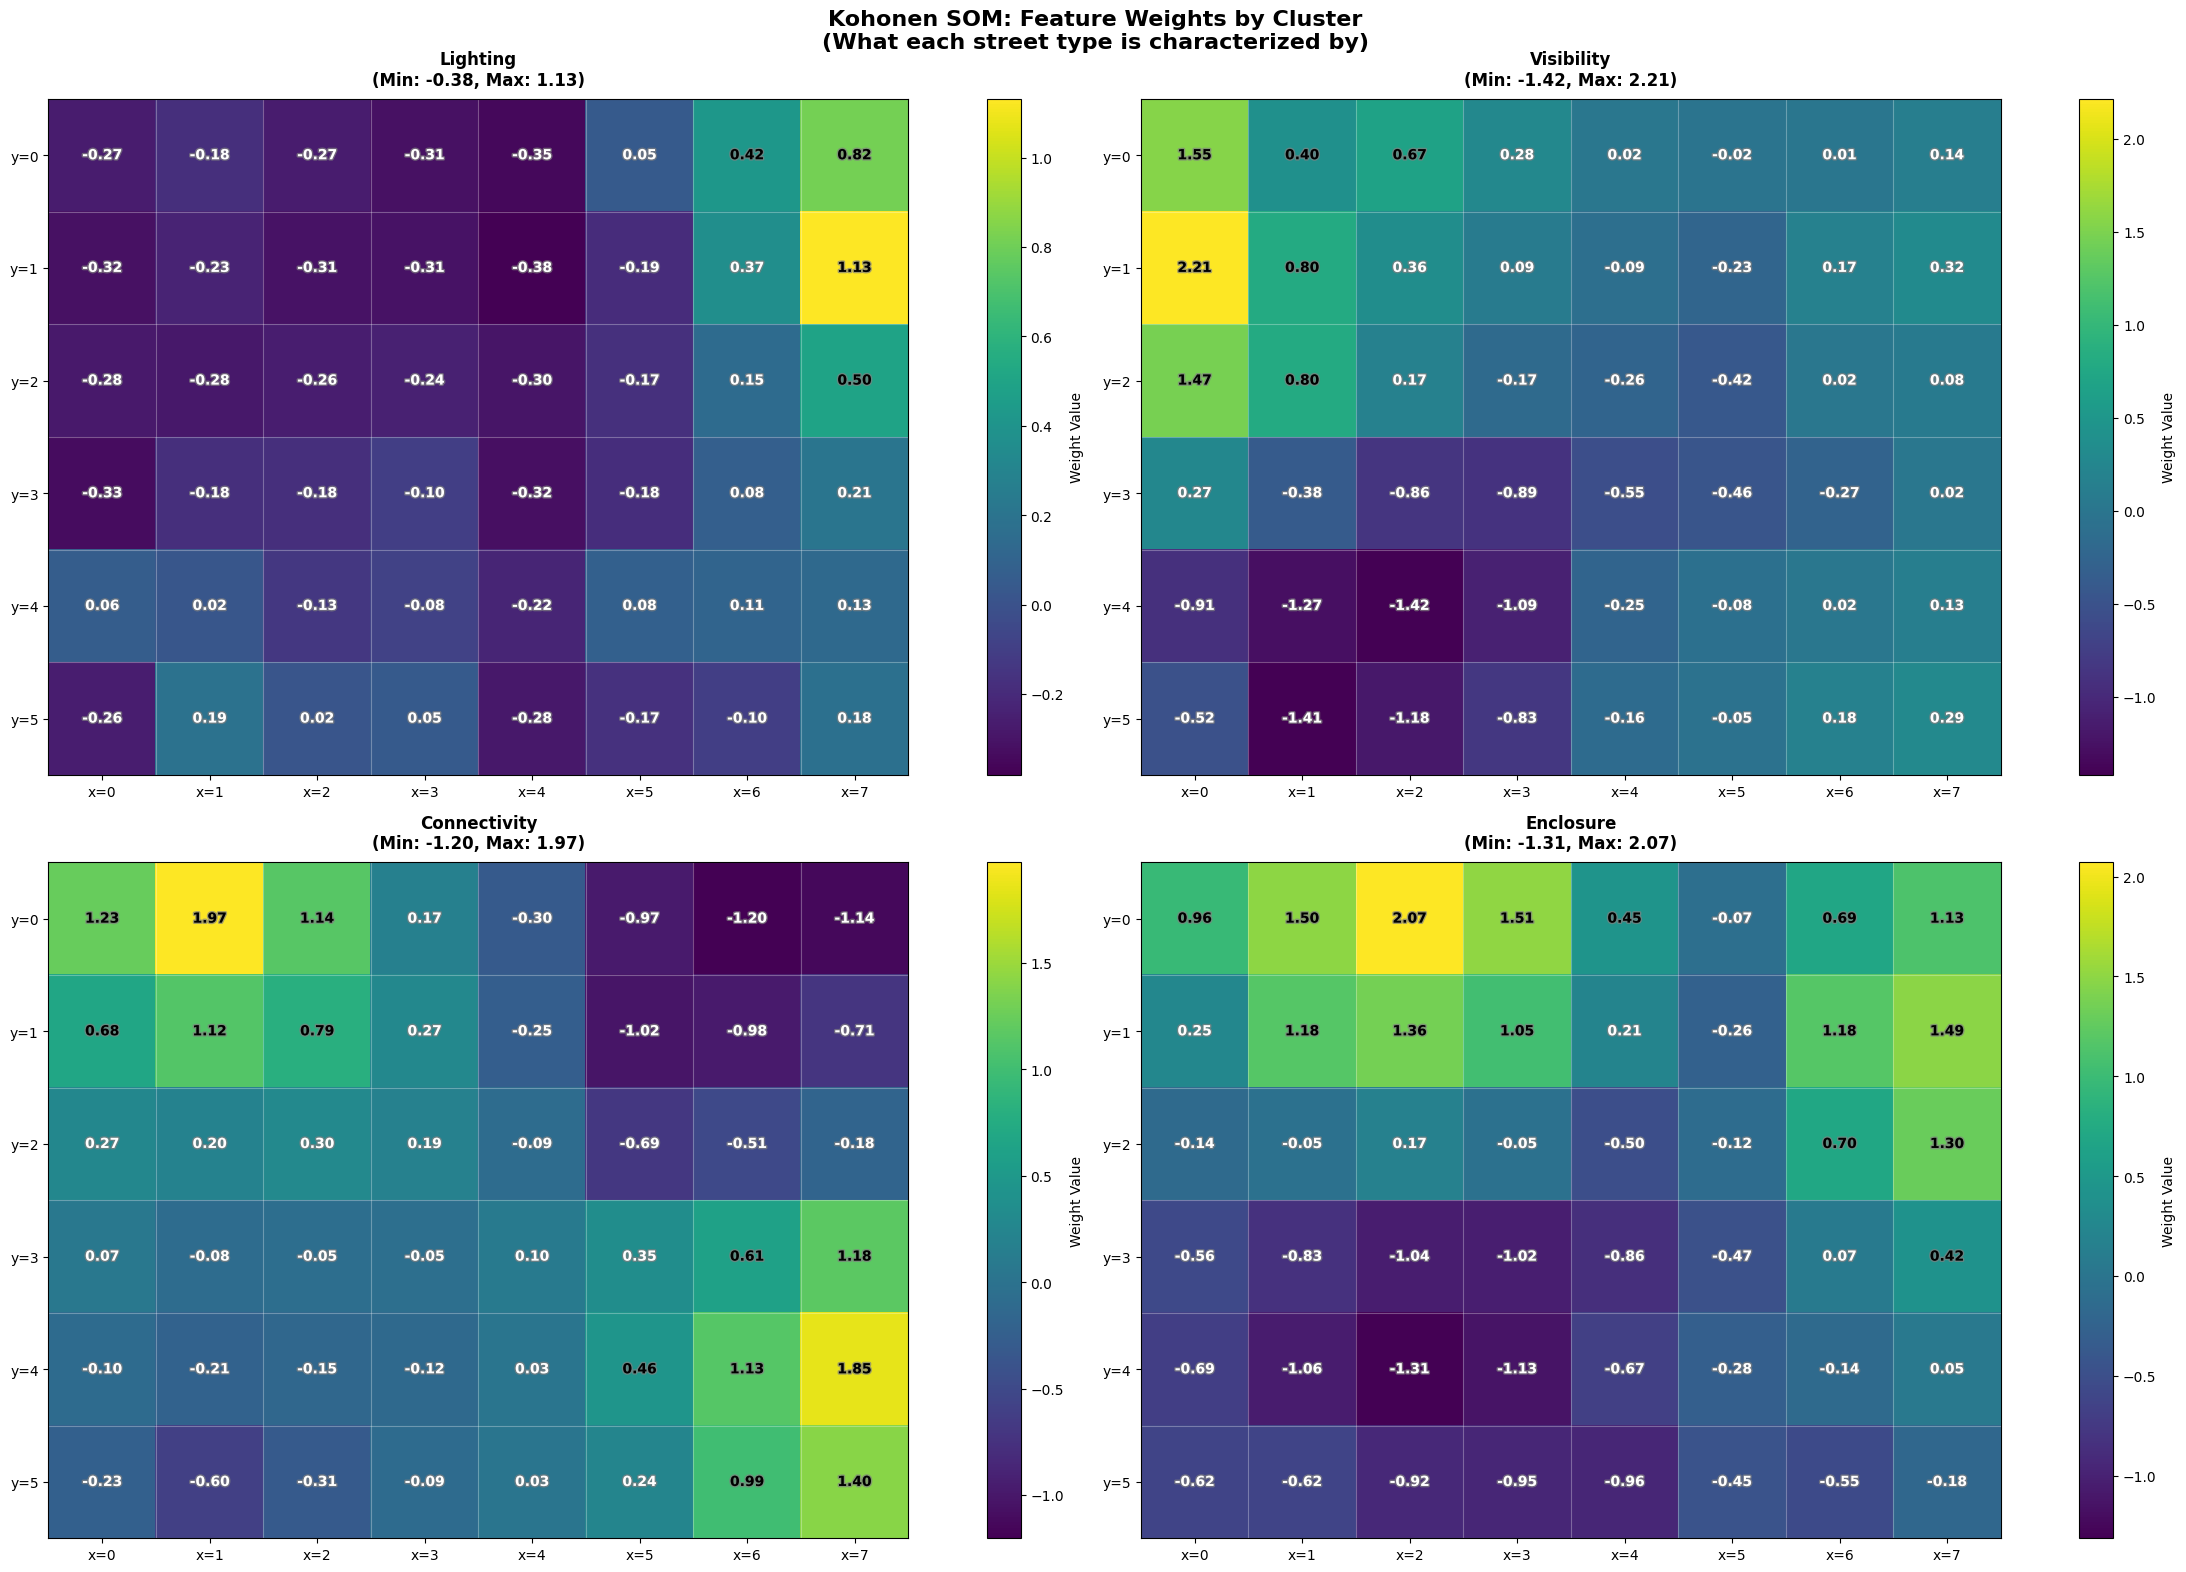

✓ Feature weights saved to C:\Users\maria\Documents\GitHub\DataEncoding_G02_Urban-Safety\plots\kohonen\som_weights.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(22, 16))
fig.suptitle('Kohonen SOM: Feature Weights by Cluster\n(What each street type is characterized by)', 
             fontsize=16, fontweight='bold', y=0.98)

feature_list = ['lighting', 'visibility', 'connectivity', 'enclosure']

for idx, (ax, feature) in enumerate(zip(axes.flat, feature_list)):
    # Get weights for this feature and TRANSPOSE
    weights = som.get_weights()[:, :, idx].T  # Now shape is (6, 8) for imshow
    
    # Draw heatmap
    im = ax.imshow(weights, cmap='viridis', aspect='auto', interpolation='nearest')
    
    # Add text values - iterate through actual dimensions
    for y in range(weights.shape[0]):  # y: 0-5 (6 rows)
        for x in range(weights.shape[1]):  # x: 0-7 (8 columns)
            val = weights[y, x]
            
            # Determine text color based on normalized brightness
            norm_val = (val - weights.min()) / (weights.max() - weights.min() + 1e-10)
            text_color = "white" if norm_val < 0.5 else "black"
            
            # Add text with proper styling
            ax.text(x, y, f'{val:.2f}', 
                   ha="center", va="center", 
                   color=text_color, 
                   fontsize=10, 
                   fontweight='bold',
                   path_effects=[path_effects.withStroke(linewidth=2, 
                                                         foreground='gray', 
                                                         alpha=0.7)])
    
    # Styling
    ax.set_xticks(range(weights.shape[1]))
    ax.set_yticks(range(weights.shape[0]))
    ax.set_xticklabels([f'x={i}' for i in range(weights.shape[1])], fontsize=10)
    ax.set_yticklabels([f'y={i}' for i in range(weights.shape[0])], fontsize=10)
    ax.set_title(f'{feature.capitalize()}\n(Min: {weights.min():.2f}, Max: {weights.max():.2f})', 
                fontweight='bold', fontsize=12, pad=10)
    
    # Add colorbar with proper spacing to avoid text overlap
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.08)
    cbar.set_label('Weight Value', fontsize=10)
    
    # Grid for better readability
    for i in range(weights.shape[1] + 1):
        ax.axvline(i - 0.5, color='white', linestyle='-', linewidth=0.8, alpha=0.3)
    for j in range(weights.shape[0] + 1):
        ax.axhline(j - 0.5, color='white', linestyle='-', linewidth=0.8, alpha=0.3)

plt.tight_layout()
weights_path = os.path.join(output_dir, 'som_weights.png')
plt.savefig(weights_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Feature weights saved to {weights_path}")

In [24]:
# First, check which neurons have segments assigned
print("Checking neuron occupancy...")
neuron_counts = np.zeros((6, 8))
for idx, row in df.iterrows():
    x, y = int(row['som_x']), int(row['som_y'])
    neuron_counts[y, x] += 1

used_neurons = np.sum(neuron_counts > 0)
total_neurons = 8 * 6
print(f"Neurons with segments: {used_neurons}/{total_neurons}")
print(f"\nSegments per neuron:")
print(neuron_counts.astype(int))

Checking neuron occupancy...
Neurons with segments: 48/48

Segments per neuron:
[[1149 2990  395  780  150  484  268  829]
 [ 653 2321  528 2952 3703  452  392 1371]
 [ 888   93  218 1939 1518  304  144   67]
 [  65  114   72  198 1117  162   88  265]
 [ 218   14   44  504 1763  510  223  265]
 [1516  195 1018 1023  293  789  508  428]]


## Visualize Distribution of Clusters by Crime

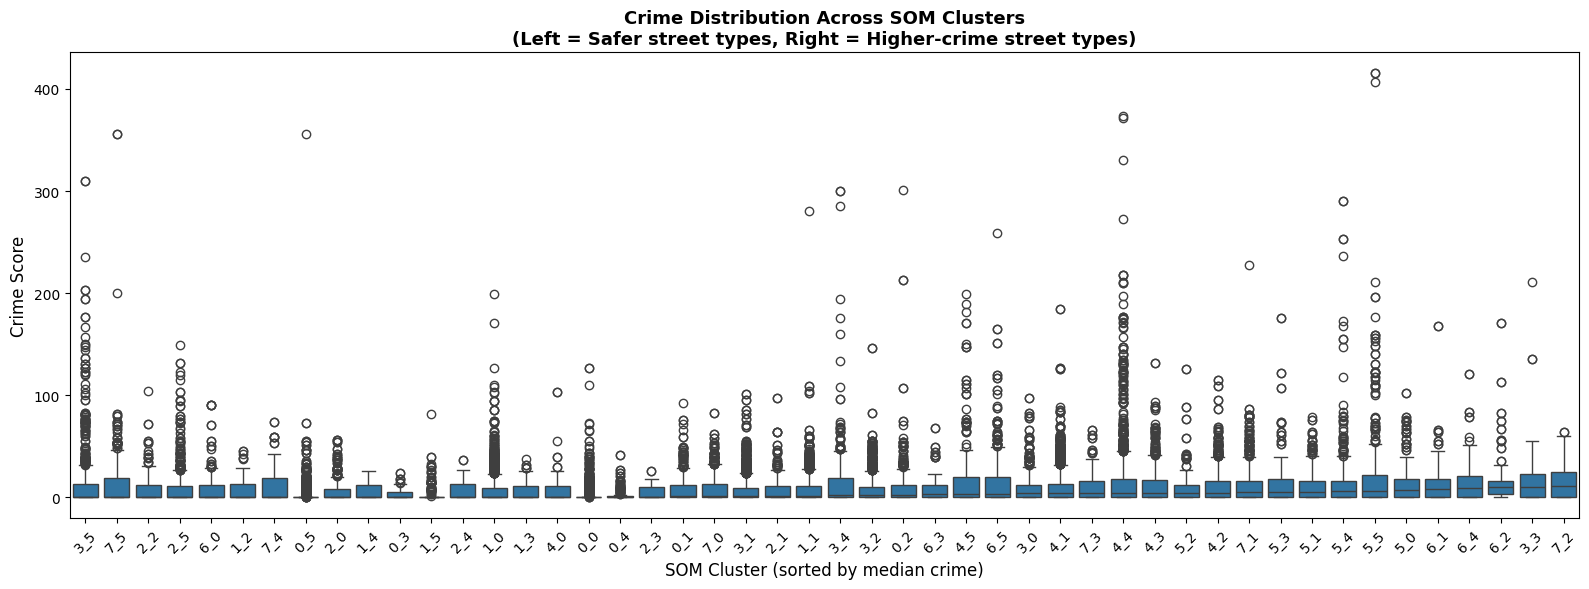

✓ Box plot saved to C:\Users\maria\Documents\GitHub\DataEncoding_G02_Urban-Safety\plots\kohonen\som_clusters_boxplot.png


In [ ]:
# Box plot of crime by SOM cluster
fig, ax = plt.subplots(figsize=(16, 6))

# Sort clusters by median crime
cluster_order = cluster_df.sort_values('crime_median')['cluster'].tolist()

sns.boxplot(data=df, x='som_cluster', y='crime_count', order=cluster_order, ax=ax)
ax.set_xlabel('SOM Cluster (sorted by median crime)', fontsize=12)
ax.set_ylabel('Crime Count', fontsize=12)
ax.set_title('Crime Distribution Across SOM Clusters\n(Left = Safer street types, Right = Higher-crime street types)', 
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
boxplot_path = os.path.join(output_dir, 'som_clusters_boxplot.png')
plt.savefig(boxplot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Box plot saved to {boxplot_path}")

## Geographic Distribution of Street Types

In [33]:
# Show which boroughs have which street types
print("\nSOM Cluster Distribution by Borough:")
print("="*100)

cluster_by_borough = pd.crosstab(df['borough'], df['som_cluster'], margins=True)
print(cluster_by_borough)


SOM Cluster Distribution by Borough:
som_cluster                                   0_0  0_1  0_2  0_3  0_4   0_5  \
borough                                                                       
City of Westminster, London, UK               263   98  110   20   36   231   
London Borough of Hackney, London, UK         160  140  165   16   32   219   
London Borough of Islington, London, UK       130   93  187    0   28   152   
London Borough of Southwark, London, UK       278  193  207    9   66   578   
London Borough of Tower Hamlets, London, UK   318  129  219   20   56   336   
All                                          1149  653  888   65  218  1516   

som_cluster                                   1_0   1_1  1_2  1_3  ...  6_3  \
borough                                                            ...        
City of Westminster, London, UK               323   122    9   16  ...   48   
London Borough of Hackney, London, UK         551   418   31   32  ...    4   
London Boroug

## Export Results

In [34]:
# Save full dataset with SOM assignments
# Use only columns that exist in the dataframe
available_cols = ['borough', 'location_id', 'lighting', 'visibility', 
                  'connectivity', 'enclosure', 'crime_score', 'crime_count', 'safety_class',
                  'som_cluster', 'som_x', 'som_y']

df_export = df[available_cols].copy()
df_export.to_csv('features_with_som_clusters.csv', index=False)
print(f"✓ Saved {len(df_export):,} segments with SOM assignments")

# Save cluster statistics
cluster_df.to_csv('som_cluster_statistics.csv', index=False)
print(f"✓ Saved cluster statistics (48 clusters)")

print("\n✓ Export complete!")

✓ Saved 35,980 segments with SOM assignments
✓ Saved cluster statistics (48 clusters)

✓ Export complete!


## Summary & Interpretation

### What the SOM reveals:

1. **High-crime street types** are characterized by:
   - **More enclosed spaces** (building coverage +0.18)
   - **Higher connectivity** (more intersections, complex networks)
   - These are typically urban cores with tall buildings and intricate street patterns

2. **Low-crime street types** have:
   - **Open, exposed areas** (low enclosure)
   - **Lower connectivity** (simpler, less complex networks)
   - Often suburban or peripheral areas with sparser development

3. **What this means**:
   - Street geometry alone doesn't *cause* crime
   - But certain street types (enclosed, complex intersections) correlate with crime hotspots
   - This could reflect: population density, foot traffic, social factors, economic activity
   - Or: crime follows opportunity (more people, more potential targets)

### Why SOM beats classification models:
- **No class imbalance** (50% "safe" in original classification)
- **Unsupervised** — doesn't force features into predefined categories
- **Pattern discovery** — reveals meaningful street type archetypes
- **Spatial interpretability** — similar streets cluster together on the grid